In [ ]:
!pip install tensorflow scikit-learn xgboost matplotlib seaborn scipy -q

from google.colab import files
import io, os
import pandas as pd
import numpy as np


df = pd.read_csv("complete_combined_matrix.csv")
print("Loaded:", df.shape)
print("Columns preview:", df.columns[:5].tolist())
print("Last 5 columns:", df.columns[-5:].tolist())

Loaded: (10701, 1647)
Columns preview: ['Gene', 'FPKM', 'PROM_MA0002.3_Runx1', 'PROM_MA0003.5_TFAP2A', 'PROM_MA0004.1_Arnt']
Last 5 columns: ['log_gene_length', 'H3K27Ac_x_H3K4Me3', 'enhancer_score', 'log_H3K27Ac', 'log_H3K4Me3']


PROM motif features:   818
ENH  motif features:   817
Histone/seq features:  11
Histone cols: ['Gene', 'half_life', 'H3K4Me3', 'H3K27Ac', 'GC_content', 'CpG_OE', 'log_gene_length', 'H3K27Ac_x_H3K4Me3', 'enhancer_score', 'log_H3K27Ac', 'log_H3K4Me3']

Expression stats:
  mean: 4.249
  std:  2.137
  min:  1.0
  max:  14.153

NaN in X: 0
NaN in y: 0


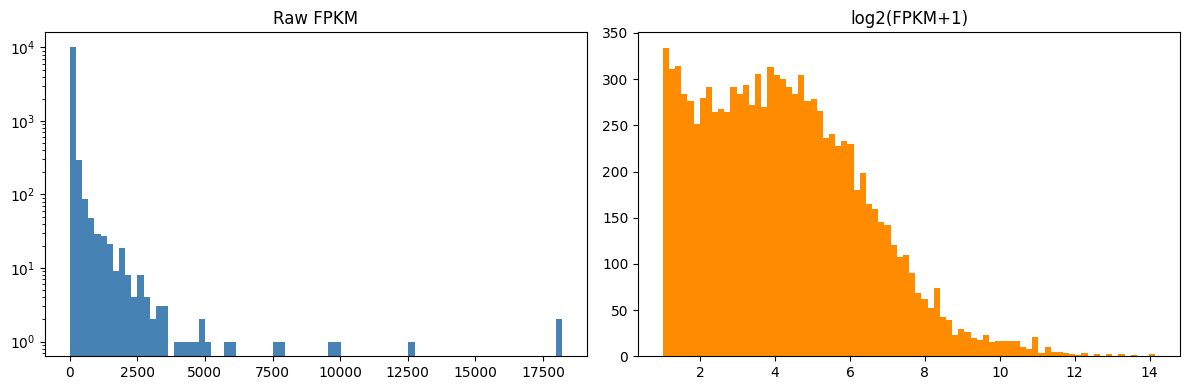

In [ ]:
# Identify feature groups
prom_cols = [c for c in df.columns if c.startswith("PROM_")]
enh_cols  = [c for c in df.columns if c.startswith("ENH_")]
hist_cols = [c for c in df.columns if c not in prom_cols + enh_cols + ["FPKM"]]

print("PROM motif features:  ", len(prom_cols))
print("ENH  motif features:  ", len(enh_cols))
print("Histone/seq features: ", len(hist_cols))
print("Histone cols:", hist_cols)

# Target: log2(FPKM+1)
y = np.log2(df["FPKM"] + 1)
X = df.drop(columns=["FPKM"])

print("\nExpression stats:")
print("  mean:", round(y.mean(), 3))
print("  std: ", round(y.std(),  3))
print("  min: ", round(y.min(),  3))
print("  max: ", round(y.max(),  3))

# Verify no NaN
print("\nNaN in X:", X.isna().sum().sum())
print("NaN in y:", y.isna().sum())

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["FPKM"],      bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Raw FPKM");  axes[0].set_yscale("log")
axes[1].hist(y,               bins=80, color="darkorange", edgecolor="none")
axes[1].set_title("log2(FPKM+1)")
plt.tight_layout(); plt.savefig("fpkm_dist.png", dpi=150); plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Stratified split
y_q = pd.qcut(y, q=4, labels=False, duplicates="drop")
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_q
)
print("Train:", len(X_tr), "  Test:", len(X_te))

# Drop 'Gene' column before scaling, as it's a string identifier.
# RobustScaler expects numerical input.
if 'Gene' in X_tr.columns:
    X_tr_numerical = X_tr.drop(columns=['Gene'])
    X_te_numerical = X_te.drop(columns=['Gene'])
else:
    X_tr_numerical = X_tr
    X_te_numerical = X_te

# Scale ALL numerical features together with RobustScaler
scaler = RobustScaler()
X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr_numerical),
                        columns=X_tr_numerical.columns, index=X_tr_numerical.index)
X_te_sc = pd.DataFrame(scaler.transform(X_te_numerical),
                        columns=X_te_numerical.columns, index=X_te_numerical.index)

# Numpy arrays for neural network
X_tr_nn = X_tr_sc.values.astype(np.float32)
X_te_nn = X_te_sc.values.astype(np.float32)
y_tr_nn = y_tr.values.astype(np.float32)
y_te_nn = y_te.values.astype(np.float32)

# Also prepare separate feature group arrays for ablation study
# Filter original feature lists to only include columns present in the scaled data
prom_cols_filtered = [c for c in prom_cols if c in X_tr_sc.columns]
enh_cols_filtered  = [c for c in enh_cols if c in X_tr_sc.columns]
hist_cols_filtered = [c for c in hist_cols if c in X_tr_sc.columns]

n_prom = len(prom_cols_filtered)
n_enh  = len(enh_cols_filtered)
n_hist = len(hist_cols_filtered)

# Feature group indices in scaled matrix
prom_idx = [X_tr_sc.columns.get_loc(c) for c in prom_cols_filtered]
enh_idx  = [X_tr_sc.columns.get_loc(c) for c in enh_cols_filtered]
hist_idx = [X_tr_sc.columns.get_loc(c) for c in hist_cols_filtered]

print("Feature groups ready:")
print("  PROM indices: 0 to", n_prom-1)
print("  ENH  indices:", n_prom, "to", n_prom+n_enh-1)
print("  HIST indices:", n_prom+n_enh, "to", n_prom+n_enh+n_hist-1)

Train: 8560   Test: 2141
Feature groups ready:
  PROM indices: 0 to 817
  ENH  indices: 818 to 1634
  HIST indices: 1635 to 1644


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr

results = {}

def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    r2   = r2_score(yte, pred)
    r, p = pearsonr(yte, pred)
    rs,_ = spearmanr(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"\n=== {name} ===")
    print(f"  R²:       {r2:.4f}")
    print(f"  Pearson:  {r:.4f}  p={p:.2e}")
    print(f"  Spearman: {rs:.4f}")
    print(f"  RMSE:     {rmse:.4f}")
    results[name] = {"R2":round(r2,4), "Pearson":round(r,4),
                     "Spearman":round(rs,4), "RMSE":round(rmse,4)}
    return model, pred

# Ridge
ridge, ridge_pred = evaluate("Ridge (all features)",
    Ridge(alpha=1.0), X_tr_sc, X_te_sc, y_tr, y_te)

# XGBoost
xgb, xgb_pred = evaluate("XGBoost (all features)",
    XGBRegressor(n_estimators=300, learning_rate=0.05,
                 max_depth=5, subsample=0.7,
                 colsample_bytree=0.5, n_jobs=-1,
                 random_state=42, verbosity=0),
    X_tr_sc.values, X_te_sc.values, y_tr, y_te)


=== Ridge (all features) ===
  R²:       0.1415
  Pearson:  0.4556  p=3.29e-110
  Spearman: 0.4533
  RMSE:     1.9352

=== XGBoost (all features) ===
  R²:       0.3188
  Pearson:  0.5656  p=2.78e-181
  Spearman: 0.5587
  RMSE:     1.7238


=== ABLATION STUDY ===
Which feature group contributes most to prediction?

  PROM only (2kb motifs)               R²=0.0372  Pearson=0.2894  █


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.95361e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  ENH only  (150kb motifs)             R²=-0.0359  Pearson=0.1776  
  HIST only (histone+seq)              R²=0.1770  Pearson=0.4224  ████████


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.27239e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  PROM + ENH (no histone)              R²=-0.0156  Pearson=0.2993  
  PROM + HIST (no enhancer)            R²=0.1961  Pearson=0.4696  █████████


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.94301e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  ENH  + HIST (no promoter)            R²=0.1501  Pearson=0.4263  ███████


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.26334e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  ALL features                         R²=0.1415  Pearson=0.4556  ███████


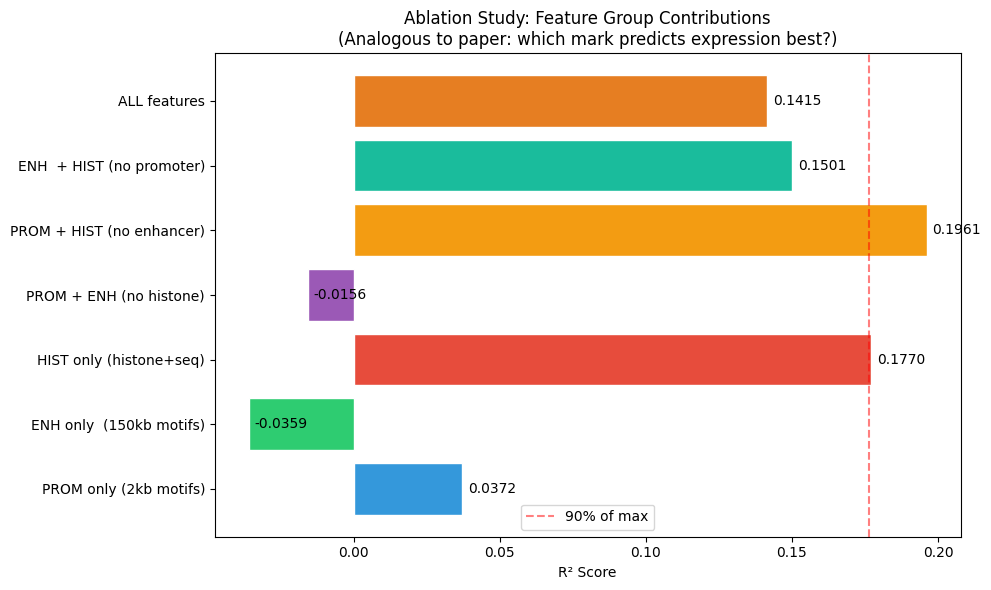


This is your key result — save this figure for your report!


In [ ]:
# This is your key scientific result — analogous to the paper
print("=== ABLATION STUDY ===")
print("Which feature group contributes most to prediction?\n")

groups = {
    "PROM only (2kb motifs)":     prom_idx,
    "ENH only  (150kb motifs)":   enh_idx,
    "HIST only (histone+seq)":    hist_idx,
    "PROM + ENH (no histone)":    prom_idx + enh_idx,
    "PROM + HIST (no enhancer)":  prom_idx + hist_idx,
    "ENH  + HIST (no promoter)":  enh_idx  + hist_idx,
    "ALL features":               prom_idx + enh_idx + hist_idx,
}

ablation_results = {}
for name, idx in groups.items():
    Xtr = X_tr_nn[:, idx]
    Xte = X_te_nn[:, idx]
    m = Ridge(alpha=1.0)
    m.fit(Xtr, y_tr_nn)
    pred = m.predict(Xte)
    r2   = r2_score(y_te_nn, pred)
    r, _ = pearsonr(y_te_nn, pred)
    ablation_results[name] = {"R2": round(r2,4), "Pearson": round(r,4)}
    bar = "█" * int(r2 * 50) if r2 > 0 else ""
    print(f"  {name:35s}  R²={r2:.4f}  Pearson={r:.4f}  {bar}")

# Plot ablation
fig, ax = plt.subplots(figsize=(10, 6))
names = list(ablation_results.keys())
r2s   = [ablation_results[n]["R2"] for n in names]
colors = ["#3498db","#2ecc71","#e74c3c",
          "#9b59b6","#f39c12","#1abc9c","#e67e22"]
bars = ax.barh(names, r2s, color=colors, edgecolor="white")
for bar, val in zip(bars, r2s):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.set_xlabel("R² Score")
ax.set_title("Ablation Study: Feature Group Contributions\n"
             "(Analogous to paper: which mark predicts expression best?)")
ax.axvline(x=max(r2s)*0.9, color="red", linestyle="--",
           alpha=0.5, label="90% of max")
ax.legend()
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nThis is your key result — save this figure for your report!")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

n_total = X_tr_nn.shape[1]

def build_dnn(n_features, dropout=0.3, l2=1e-4, lr=1e-3):
    inp = keras.Input(shape=(n_features,))

    # Branch 1: Promoter motifs
    p_in  = layers.Lambda(lambda x: x[:, :n_prom])(inp)
    p     = layers.Dense(256, kernel_regularizer=regularizers.l2(l2))(p_in)
    p     = layers.BatchNormalization()(p)
    p     = layers.Activation("relu")(p)
    p     = layers.Dropout(dropout)(p)
    p     = layers.Dense(128)(p)
    p     = layers.Activation("relu")(p)

    # Branch 2: Enhancer motifs
    e_in  = layers.Lambda(lambda x: x[:, n_prom:n_prom+n_enh])(inp)
    e     = layers.Dense(256, kernel_regularizer=regularizers.l2(l2))(e_in)
    e     = layers.BatchNormalization()(e)
    e     = layers.Activation("relu")(e)
    e     = layers.Dropout(dropout)(e)
    e     = layers.Dense(128)(e)
    e     = layers.Activation("relu")(e)

    # Branch 3: Histone + sequence features
    h_in  = layers.Lambda(lambda x: x[:, n_prom+n_enh:])(inp)
    h     = layers.Dense(32)(h_in)
    h     = layers.Activation("relu")(h)
    h     = layers.Dense(32)(h)
    h     = layers.Activation("relu")(h)

    # Merge all branches
    merged = layers.Concatenate()([p, e, h])
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout/2)(x)
    x = layers.Dense(64)(x)
    x = layers.Activation("relu")(x)
    out = layers.Dense(1)(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="huber",
        metrics=["mae"]
    )
    return model

model = build_dnn(n_total)
model.summary()

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=25,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=10, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint("best_dnn.keras", monitor="val_loss",
                               save_best_only=True)
]

print("\nTraining branched DNN (PROM + ENH + HIST branches)...")
history = model.fit(
    X_tr_nn, y_tr_nn,
    validation_split=0.15,
    epochs=300,
    batch_size=256,
    callbacks=cb_list,
    verbose=1
)

TF: 2.20.0
GPU: []


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1645)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 818)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 817)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    209,664 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    209,408 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 10)        │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        352 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32)        │          0 │ dense_4[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,056 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128)       │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32)        │          0 │ dense_5[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 605,057 (2.31 MB)

 Trainable params: 603,265 (2.30 MB)

 Non-trainable params: 1,792 (7.00 KB)


Training branched DNN (PROM + ENH + HIST branches)...
Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 2.1423 - mae: 2.4922 - val_loss: 1.7265 - val_mae: 2.0618 - learning_rate: 0.0010
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 1.2432 - mae: 1.5697 - val_loss: 1.8872 - val_mae: 2.2223 - learning_rate: 0.0010
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.1051 - mae: 1.4220 - val_loss: 1.8644 - val_mae: 2.2081 - learning_rate: 0.0010
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.0521 - mae: 1.3648 - val_loss: 1.7186 - val_mae: 2.0533 - learning_rate: 0.0010
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.0000 - mae: 1.3120 - val_loss: 1.5097 - val_mae: 1.8372 - learning_rate: 0.0010
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.9411 - mae: 1.2454 - val_loss: 1.4152 - val_mae: 1.7397 - learning_rate: 0.0010
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.8983 - mae: 1.2009 - val_loss: 

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
  BRANCHED DNN RESULTS
  R²:       0.1489
  Pearson:  0.4954  p=5.59e-133
  Spearman: 0.4830

=== FINAL MODEL COMPARISON ===
                   R2  Pearson  Spearman    RMSE
Ridge (all)    0.1415   0.4556    0.4533  1.9352
Branched DNN   0.1489   0.4954    0.4830     NaN
XGBoost (all)  0.3188   0.5656    0.5587  1.7238


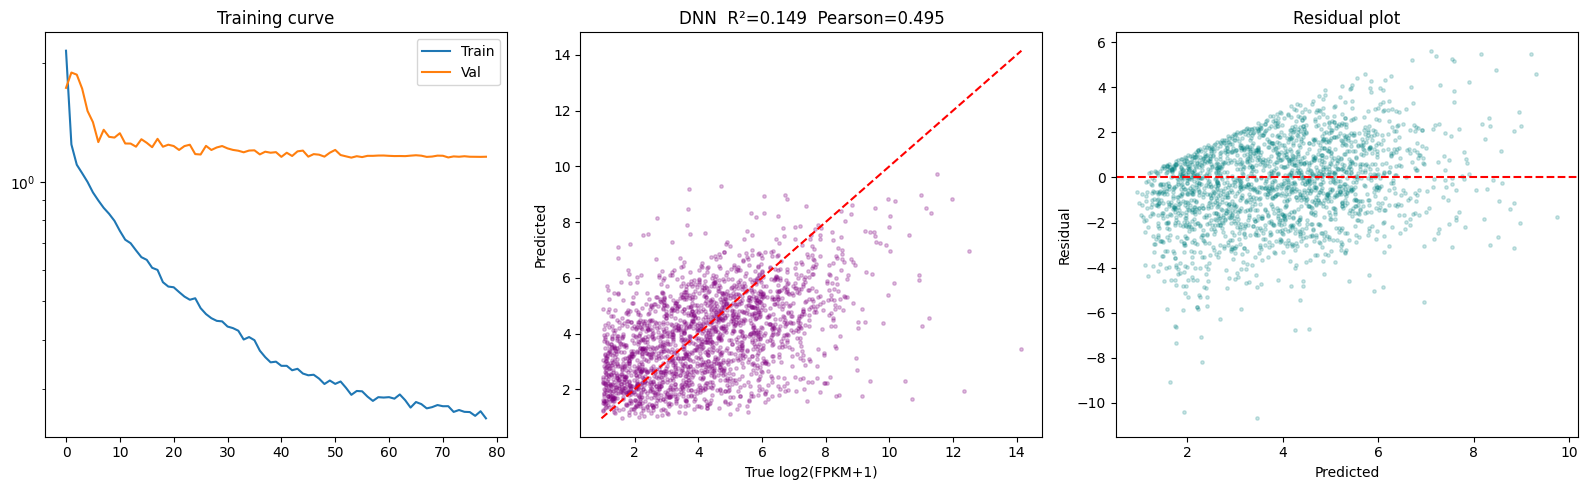

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dnn_pred = model.predict(X_te_nn).flatten()
r2_dnn   = r2_score(y_te_nn, dnn_pred)
r_dnn, p_dnn = pearsonr(y_te_nn, dnn_pred)
rs_dnn,_ = spearmanr(y_te_nn, dnn_pred)

print("="*45)
print("  BRANCHED DNN RESULTS")
print("="*45)
print(f"  R²:       {r2_dnn:.4f}")
print(f"  Pearson:  {r_dnn:.4f}  p={p_dnn:.2e}")
print(f"  Spearman: {rs_dnn:.4f}")

# Final comparison table
all_results = pd.DataFrame({
    "Ridge (all)":      results.get("Ridge (all features)",   {}),
    "XGBoost (all)":    results.get("XGBoost (all features)", {}),
    "Branched DNN":     {"R2":round(r2_dnn,4),
                         "Pearson":round(r_dnn,4),
                         "Spearman":round(rs_dnn,4)},
}).T.sort_values("R2", ascending=True)

print("\n=== FINAL MODEL COMPARISON ===")
print(all_results.to_string())

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history.history["loss"],     label="Train", linewidth=1.5)
axes[0].plot(history.history["val_loss"], label="Val",   linewidth=1.5)
axes[0].set_title("Training curve"); axes[0].legend()
axes[0].set_yscale("log")

axes[1].scatter(y_te_nn, dnn_pred, alpha=0.25, s=6, color="purple")
mn = min(y_te_nn.min(), dnn_pred.min())
mx = max(y_te_nn.max(), dnn_pred.max())
axes[1].plot([mn,mx],[mn,mx], "r--", linewidth=1.5)
axes[1].set_xlabel("True log2(FPKM+1)")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"DNN  R²={r2_dnn:.3f}  Pearson={r_dnn:.3f}")

residuals = dnn_pred - y_te_nn
axes[2].scatter(dnn_pred, residuals, alpha=0.2, s=6, color="teal")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residual plot")

plt.tight_layout()
plt.savefig("dnn_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Download all results
for f in ["ablation_study.png", "dnn_results.png",
          "fpkm_dist.png", "best_dnn.keras"]:
    try: files.download(f)
    except: pass

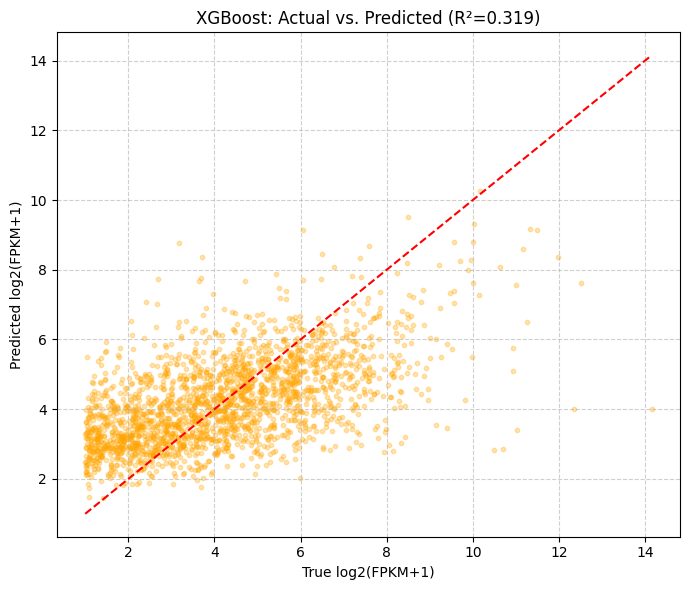

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_te, xgb_pred, alpha=0.3, s=10, color="orange")

mn = min(y_te.min(), xgb_pred.min())
mx = max(y_te.max(), xgb_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)

plt.xlabel("True log2(FPKM+1)")
plt.ylabel("Predicted log2(FPKM+1)")
plt.title(f"XGBoost: Actual vs. Predicted (R²={results['XGBoost (all features)']['R2']:.3f})")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("xgboost_actual_vs_predicted.png", dpi=150)
plt.show()